                                        Review Sentiment
0  Product quality is excellent and I loved it  Positive
1     Delivery was very slow and disappointing  Negative
2          Amazing customer support experience  Positive
3                     The item arrived damaged  Negative
4                 Very happy with the purchase  Positive

Dataset Shape:
(20, 2)

Accuracy: 0.25

Classification Report:

              precision    recall  f1-score   support

    Negative       0.00      0.00      0.00         3
    Positive       0.25      1.00      0.40         1

    accuracy                           0.25         4
   macro avg       0.12      0.50      0.20         4
weighted avg       0.06      0.25      0.10         4



C:\Users\Riyaz\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Riyaz\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Riyaz\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


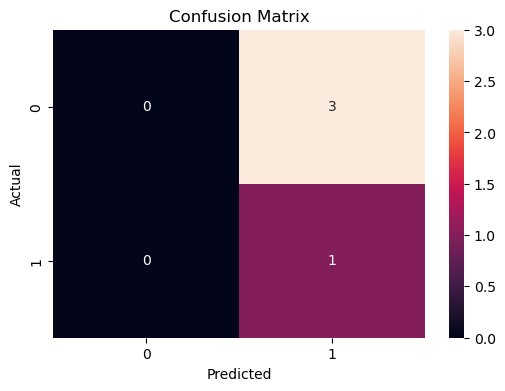

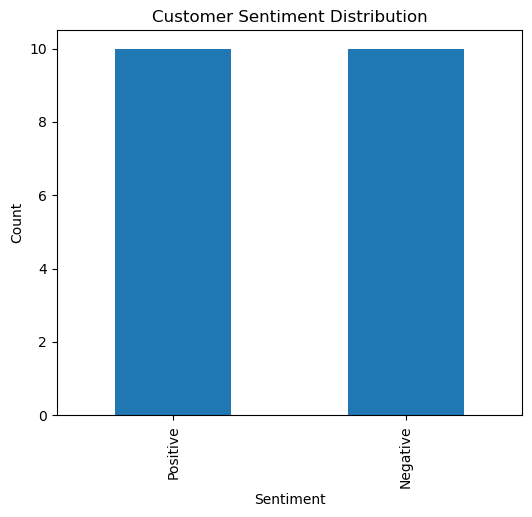


Review: This product is amazing and quality is excellent
Predicted Sentiment: Positive


In [1]:
# ==========================================
# Customer Feedback Sentiment Analysis
# Moderate-Level Data Analytics Project
# ==========================================

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix
import seaborn as sns

# ==========================================
# Load Dataset
# ==========================================

df = pd.read_csv("customer_feedback.csv")

# Display first rows
print(df.head())

# Dataset should contain:
# Review = customer review text
# Sentiment = Positive / Negative

# ==========================================
# Data Cleaning
# ==========================================

# Remove missing values
df.dropna(inplace=True)

# Remove duplicate values
df.drop_duplicates(inplace=True)

print("\nDataset Shape:")
print(df.shape)

# ==========================================
# Feature Selection
# ==========================================

X = df["Review"]
y = df["Sentiment"]

# ==========================================
# Convert Text into Numbers
# TF-IDF Vectorization
# ==========================================

vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(X)

# ==========================================
# Split Dataset
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# ==========================================
# Train Model
# ==========================================

model = MultinomialNB()

model.fit(X_train, y_train)

# ==========================================
# Prediction
# ==========================================

y_pred = model.predict(X_test)

# ==========================================
# Model Evaluation
# ==========================================

accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:", accuracy)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# ==========================================
# Confusion Matrix Visualization
# ==========================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# ==========================================
# Sentiment Distribution
# ==========================================

plt.figure(figsize=(6,5))

df["Sentiment"].value_counts().plot(
    kind="bar"
)

plt.title("Customer Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")

plt.show()

# ==========================================
# Predict New Review
# ==========================================

new_review = ["This product is amazing and quality is excellent"]

new_data = vectorizer.transform(new_review)

prediction = model.predict(new_data)

print("\nReview:", new_review[0])
print("Predicted Sentiment:", prediction[0])
